7. Build a machine learning model to predict crop yield using historical weather and soil data to assist farmers in decision-making

In [1]:
import pandas as pd

crop = pd.read_csv("https://drive.google.com/uc?id=1Ms_e5ZRf37_kHVRSFyvHkly_13bYRGOy")
soil = pd.read_csv("https://drive.google.com/uc?id=1fmkbFjzVBtNokqSt1mVTN6uXQP7c07lD")
weather = pd.read_csv("https://drive.google.com/uc?id=14EENZjEDSmsN2eN_s2nNkHUkspUktYmT")

In [2]:
print(crop.shape)
print(soil.shape)
print(weather.shape)

print(crop.columns)
print(soil.columns)
print(weather.columns)

(19689, 9)
(30, 5)
(720, 5)
Index(['crop', 'year', 'season', 'state', 'area', 'production', 'fertilizer',
       'pesticide', 'yield'],
      dtype='object')
Index(['state', 'N', 'P', 'K', 'pH'], dtype='object')
Index(['state', 'year', 'avg_temp_c', 'total_rainfall_mm',
       'avg_humidity_percent'],
      dtype='object')


In [3]:
crop.columns = crop.columns.str.strip()
soil.columns = soil.columns.str.strip()
weather.columns = weather.columns.str.strip()

In [4]:
df = pd.merge(crop, weather, on=["state", "year"], how="inner")

In [5]:
df = pd.merge(df, soil, on="state", how="inner")

In [6]:
df.head()
df.shape

(19689, 16)

In [7]:
X = df.drop("yield", axis=1)
y = df["yield"]

In [8]:
X = pd.get_dummies(X, drop_first=True)

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [10]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [11]:
y_pred = model.predict(X_test)

In [12]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Squared Error: 13123.063005049198
R2 Score: 0.9836215550675913


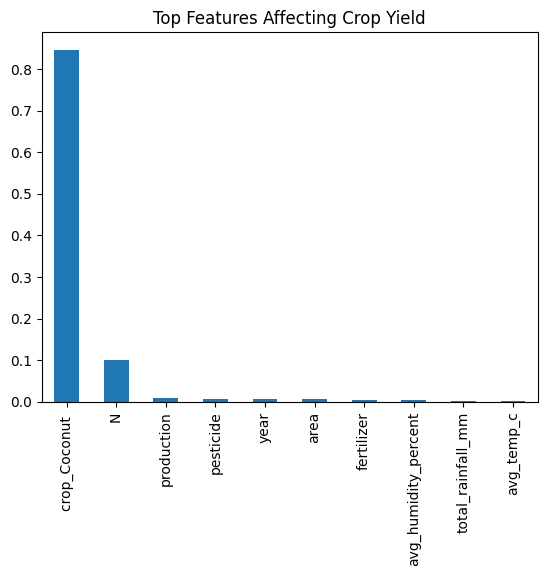

In [13]:
import matplotlib.pyplot as plt

importances = model.feature_importances_

feature_importance = pd.Series(importances, index=X.columns)

feature_importance.sort_values(ascending=False).head(10).plot(kind='bar')

plt.title("Top Features Affecting Crop Yield")
plt.show()

It tells : Which input features had the biggest impact on predicting crop yield?

Meaning : The type of crop (specifically Coconut) has the strongest influence on yield prediction